# PandasAI Quickstart Guide

This notebook demonstrates how to get started with PandasAI and how to use it to analyze data through natural language.

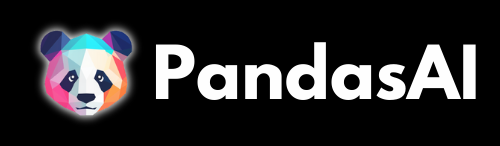


In [20]:
# Importing the required libraries
import pandas as pd
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus
from pathlib import Path
import os
from IPython.display import Image, display
import shutil
import os

def create_or_load(path, **kwargs):
    dataset_dir = f"datasets/{path}"
    if os.path.exists(dataset_dir):
        print(f"Dataset exists, loading: {path}")
        return pai.load(path)
    else:
        print(f"Creating new dataset: {path}")
        return pai.create(path=path, **kwargs)

In [21]:
# Load environment variables
load_dotenv()

True

# 1. Getting Familiar with PandasAI
This section will cover the basics of PandasAI, such as loading data and using the .chat() method to talk to it.

## Read Database Directly
For this example, we will load our data directly from our Postgres database using SQLAlquemy 

In [22]:
# Get values from .env
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [23]:
# Create connection to Postgres
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require")

In [24]:
# Connect to Postgres: load .env from project folder and create engine (no stale connection)
PROJECT_DIR = Path(r"c:\Users\TornikePeradze\pandasai-quickstart-guide")
_env_path = PROJECT_DIR / ".env"
load_dotenv(_env_path, override=True)  # override=True so .env wins over system DB_HOST
print("Loading .env from:", _env_path, "| Exists:", _env_path.exists())

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
print("DB_HOST =", repr(DB_HOST), "| DB_USER =", repr(DB_USER))

safe_pass = quote_plus(DB_PASS or "")
base_url = f"postgresql+psycopg2://{DB_USER}:{safe_pass}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
connection_url = base_url if (DB_HOST or "").strip().lower() in ("localhost", "127.0.0.1") else f"{base_url}?sslmode=require"
engine = create_engine(connection_url)

query = "SELECT * FROM customer LIMIT 1000;"
database_df = pd.read_sql(query, engine)
print("Data loaded from Postgres")

database_df.head()

Loading .env from: c:\Users\TornikePeradze\pandasai-quickstart-guide\.env | Exists: True
DB_HOST = 'localhost' | DB_USER = 'postgres'
Data loaded from Postgres


,customer_id,store_id,first_name,last_name,email,address_id,activebool,create_date,last_update,active
0,524,1,Jared,Ely,jared.ely@sakilacustomer.org,530,True,2006-02-14,2013-05-26 14:49:45.738,1
1,1,1,Mary,Smith,mary.smith@sakilacustomer.org,5,True,2006-02-14,2013-05-26 14:49:45.738,1
2,2,1,Patricia,Johnson,patricia.johnson@sakilacustomer.org,6,True,2006-02-14,2013-05-26 14:49:45.738,1
3,3,1,Linda,Williams,linda.williams@sakilacustomer.org,7,True,2006-02-14,2013-05-26 14:49:45.738,1
4,4,2,Barbara,Jones,barbara.jones@sakilacustomer.org,8,True,2006-02-14,2013-05-26 14:49:45.738,1


## Set up LLM

Use `pandasai_litellm` to select the LLM of your choice and use PandasAI

In [25]:
# Initialize LiteLLM with an OpenAI model
llm = LiteLLM(model="gpt-4.1-mini")

# Configure PandasAI to use this LLM
pai.config.set({
    "llm": llm
})

## Chat with your data
Now we will use the .chat() method to chat with our data

In [26]:
# Convert our normal pandas dataframe to a pandasai dataframe
database_df = pai.DataFrame(database_df)

In [27]:
# Chat with the dataframe
response = database_df.chat("How many active customers are there?")
print(response)

599


In [28]:
response = database_df.chat("Plot a bar chart of customers per store_id, use a different color per bar, and show the exact count on top of each bar.")

# Extract the path if needed for other purposes
chart_path = response.path if hasattr(response, 'path') else str(response)
# Don't call display() - PandasAI already displayed it

In [29]:
# Chat with the dataframe
response = database_df.chat("Which store has a higher percentage of active customers?")
print(response)

Store 1.0 has the highest percentage of active customers at 100.0%.


## Read Database using PandasAI DB Data Extensions

Now we will learn how to load our data from our Postgres database using the .create() method. This will also create a dataset (locally) which can be reloaded in the future.

In [30]:
customer_dataset = create_or_load(
    path="public/customer",
    description="DVD rental store customers with store assignment and active status",
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": int(DB_PORT),
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },
        "table": "customer"
    }
)

Dataset exists, loading: public/customer
Dataset loaded successfully.


In [31]:
# Chat with the dataset
response = customer_dataset.chat("How many active vs inactive customers are there per store?")
print(response)

   store_id  active_status  customer_count
0         1           True             326
1         2           True             273


## Load Dataset
After creation you load your datasets anytime with the following code

In [32]:
# Load the dataset we created in the previous step using the .create() method
dataset = pai.load("public/customer")

Dataset loaded successfully.


# 2. Using a Semantic Layer in PandasAI
In this section, we will explore how to use a semantic layer in PandasAI in order to improve the accuracy of the AI agent.

## Adding Column Information

In [ ]:
# Will be added in below sections

# rental_dataset = pai.create(
#     path="public/rental",
#     description="Tracks every DVD rental transaction — when it was rented, returned, and by which customer",
#     source={
#         "type": "postgres",
#         "connection": {
#             "host": DB_HOST,
#             "port": int(DB_PORT),
#             "user": DB_USER,
#             "password": DB_PASS,
#             "database": DB_NAME
#         },
#         "table": "rental",
#         "columns": [
#             {
#                 "name": "rental_id",
#                 "type": "integer",
#                 "description": "Unique identifier for each rental transaction"
#             },
#             {
#                 "name": "rental_date",
#                 "type": "datetime",
#                 "description": "Date and time when the DVD was rented out"
#             },
#             {
#                 "name": "inventory_id",
#                 "type": "integer",
#                 "description": "Foreign key linking to the specific DVD copy in inventory"
#             },
#             {
#                 "name": "customer_id",
#                 "type": "integer",
#                 "description": "Foreign key linking to the customer who rented the DVD"
#             },
#             {
#                 "name": "return_date",
#                 "type": "datetime",
#                 "description": "Date and time when the DVD was returned. NULL means not yet returned"
#             },
#             {
#                 "name": "staff_id",
#                 "type": "integer",
#                 "description": "Foreign key linking to the staff member who processed the rental"
#             }
#         ]
#     }
# )

## Enhancing Your Semantic Layer

The semantic layer you just created can be further enhanced with additional features to improve AI accuracy and data understanding:

### What else can you add?

- **Column Expressions**: Define calculated/derived columns using formulas (e.g., `total_revenue = transaction_amount * (1 + tax_rate)`)
- **Column Aliases**: Create alternative names for columns to improve natural language understanding
- **Transformations**: Apply data transformations like anonymization or timezone conversion
- **Group By**: Specify which columns can be used for grouping operations

### How to add them?

These features must be added by **editing the schema.yaml file directly** in `datasets/public/subscriptions/schema.yaml`. 

For example, to add an alias and expression:
```yaml
columns:
  - name: plan
    type: string
    description: The subscription plan
    alias: subscription_plan  # Alternative name
  - name: subscription_length_days
    type: integer
    description: Length of subscription in days
    expression: "EXTRACT(DAY FROM (COALESCE(end_date, CURRENT_DATE) - start_date))"  # Calculated column
```

For detailed documentation on building a comprehensive semantic layer, including examples of expressions, aliases, transformations, and group_by configurations, visit:

📚 **[PandasAI Semantic Layer Documentation](https://docs.pandas-ai.com/v3/semantic-layer/new)**

This will help you create a more powerful and accurate AI agent that better understands your data and business logic.

In [35]:
# Load semantic layer into memory
with open(r"C:\Users\TornikePeradze\Desktop\AI_Workflows_Bootcamp\dvd-semantic-layer\compiled_semantic_layer.yaml", "r") as f:
    semantic_context = f.read()

print("Semantic layer loaded. Characters:", len(semantic_context))

Semantic layer loaded. Characters: 18107


In [39]:
# Create payment dataset with semantic context
payment_dataset = create_or_load(
    path="public/payment",
    description=f"""Payment transactions made by customers for rentals.

{semantic_context}
""",
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": int(DB_PORT),
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME,
        },
        "table": "payment",
    },
)
print("Done: public/payment")

Dataset exists, loading: public/payment
Dataset loaded successfully.
Done: public/payment


In [40]:
payment_loaded = pai.load("public/payment")

response = payment_loaded.chat(
    "What is the total revenue and how many payments were made?"
)
print(response)

Dataset loaded successfully.
Total revenue is $61312.04 from 14596 payment transactions.


In [41]:
# Create rental dataset with semantic context
# Rental is the core transaction table — links customers to inventory items
rental_dataset = create_or_load(
    path="public/rental",
    description=f"""Rental events tracking when DVDs were rented and returned.

{semantic_context}
""",
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": int(DB_PORT),
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME,
        },
        "table": "rental",
    },
)
print("Created: public/rental")

Dataset exists, loading: public/rental
Dataset loaded successfully.
Created: public/rental


In [42]:
# Testing rental table — curious how PandasAI handles NULL return_date
# In our semantic layer, NULL return_date means DVD not yet returned
rental_loaded = pai.load("public/rental")

response = rental_loaded.chat(
    "How many rentals have not been returned yet?"
)
print(response)

# Same question, different phrasing — testing reasoning consistency
response = rental_loaded.chat(
    "What percentage of all rentals are currently still out?"
)
print(response)

## Rental Table Exploration

# I was curious whether PandasAI would correctly handle NULL values in `return_date` — 
# since in our database NULL means "not yet returned", not missing data. 

# It handled it correctly both times: 183 rentals still out, representing 1.14% of all rentals.
# Rephrasing the question produced consistent results, which is a good sign for reasoning reliability.

Dataset loaded successfully.
183
1.14


In [43]:
# Create film dataset with semantic context
film_dataset = create_or_load(
    path="public/film",
    description=f"""Film catalog with ratings, rental pricing and duration.

{semantic_context}
""",
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": int(DB_PORT),
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME,
        },
        "table": "film",
    },
)
print("Created: public/film")

Dataset exists, loading: public/film
Dataset loaded successfully.
Created: public/film


In [44]:
film_loaded = pai.load("public/film")

response = film_loaded.chat(
    "Which film rating has the highest average replacement cost and how many films does it include?"
)
print(response)

# Rephrase to test consistency
response = film_loaded.chat(
    "Rank film ratings by average replacement cost and include film counts."
)
print(response)

## Film Table Exploration

# Wanted to test PandasAI on the film catalog — specifically whether it could handle 
# a combined aggregation (average cost + count) in one question.

# PG-13 has the highest average replacement cost at $20.40 across 223 films, followed 
# closely by R and NC-17. Both phrasings returned identical results, confirming 
# reasoning consistency on this table.

# Interesting note: PG films have noticeably lower average replacement cost ($18.96) 
# compared to all other ratings — worth investigating further.

Dataset loaded successfully.
The film rating with the highest average replacement cost is 'PG-13', with an average replacement cost of $20.40 and includes 223 film(s).
  rating  avg_replacement_cost  film_count
0  PG-13             20.402556         223
1      R             20.231026         195
2  NC-17             20.137619         210
3      G             20.124831         178
4     PG             18.959072         194


In [54]:
# Multi-Table Reasoning Experiment (Join)
# Building a joined dataset across customer, rental and payment
# to ask cross-domain business questions

joined_query = """
SELECT
    c.customer_id,
    c.store_id,
    c.activebool,
    r.rental_id,
    r.rental_date,
    r.return_date,
    p.payment_id,
    p.payment_date,
    p.amount
FROM customer c
JOIN rental r ON c.customer_id = r.customer_id
JOIN payment p ON r.rental_id = p.rental_id;
"""

joined_df = pd.read_sql(joined_query, engine)
joined_df = pai.DataFrame(joined_df)

response = joined_df.chat(
    "For each store, what is the total revenue and how many unique customers contributed to it?"
)
print(response)


# Same analytical intent, different phrasing — testing reasoning consistency
response = joined_df.chat(
    "Compare average payment amount by store_id and customer active status, then identify the top combination."
)
print(response)

## Multi-Table Reasoning Experiment (Join)

# I joined customer, rental and payment tables manually and asked cross-domain questions.

# First question worked perfectly — Store 1 leads with $11,099 total revenue from 324 
# unique customers vs Store 2 with $9,909 from 272 customers.

# Second question revealed an interesting limitation: asking to "identify the top combination" 
# caused PandasAI to return only one row instead of the full breakdown. It answered the 
# "top" part but skipped the "compare" part. This tells me prompt precision matters a lot — 
# the more specific and unambiguous the question, the more reliable the output.

# Takeaway: for production use in a Slackbot, queries should be phrased as single clear 
# intents, not compound questions with multiple instructions.

   store_id  total_revenue  unique_customers
0         1       33626.39               326
1         2       27685.65               273
   store_id  activebool  avg_payment_amount
0         1        True             4.22389


In [55]:
import shutil
shutil.rmtree("datasets/public/revenue-view")

revenue_view = pai.create(
    path="public/revenue-view",
    description="Cross-table view linking customers to rentals and payments for revenue analysis.",
    relations=[
        {
            "name": "customer_to_rental",
            "description": "Links each customer to their rental history",
            "from": "customer.customer_id",
            "to": "rental.customer_id",
        },
        {
            "name": "rental_to_payment",
            "description": "Links each rental to its payment transaction",
            "from": "rental.rental_id",
            "to": "payment.rental_id",
        },
    ],
    columns=[
        {"name": "customer.customer_id", "type": "integer"},
        {"name": "customer.store_id", "type": "integer"},
        {"name": "customer.activebool", "type": "boolean"},
        {"name": "rental.rental_id", "type": "integer"},
        {"name": "rental.rental_date", "type": "datetime"},
        {"name": "rental.return_date", "type": "datetime"},
        {"name": "payment.amount", "type": "float"},
        {"name": "payment.payment_date", "type": "datetime"},
    ],
    view=True,
)
print("Revenue view recreated without full semantic context.")

Dataset saved successfully to path: public\revenue-view
Revenue view recreated without full semantic context.


In [56]:
revenue_view = pai.load("public/revenue-view")

response = revenue_view.chat(
    "What is the total revenue per store?"
)
print(response)

Dataset loaded successfully.
   store_id  total_revenue
0         1       33626.39
1         2       27685.65


In [57]:
# Question 2 - joined_df for time-based breakdown
response = joined_df.chat("Show total amount grouped by store_id and month of payment_date.")
print(response)

   store_id payment_month  total_amount
0         1       2007-02       4465.08
1         1       2007-03      13019.31
2         1       2007-04      15858.98
3         1       2007-05        283.02
4         2       2007-02       3886.76
5         2       2007-03      10867.25
6         2       2007-04      12700.48
7         2       2007-05        231.16


In [58]:
from pandasai import Agent

# Load all tables as full DataFrames (no LIMIT for accuracy)
customer_df = pd.read_sql("SELECT * FROM customer;", engine)
rental_df = pd.read_sql("SELECT * FROM rental;", engine)
payment_df = pd.read_sql("SELECT * FROM payment;", engine)

# Build multi-table agent
dvd_agent = Agent([customer_df, rental_df, payment_df])
print("Agent ready. Rows loaded:")
print("  customer:", len(customer_df))
print("  rental:", len(rental_df))
print("  payment:", len(payment_df))

Agent ready. Rows loaded:
  customer: 599
  rental: 16044
  payment: 14596


In [59]:
# Customer Behavior — who are the most valuable customers?
response = dvd_agent.chat(
    "Who are the top 10 customers by total amount spent, and how many rentals have they made?"
)
print(response)

   customer_id first_name last_name  total_amount_spent  total_rentals
0          148    Eleanor      Hunt              211.55             45
1          526       Karl      Seal              208.58             42
2          178     Marion    Snyder              194.61             39
3          137     Rhonda   Kennedy              191.62             38
4          144      Clara      Shaw              189.60             40
5          459      Tommy   Collazo              183.63             37
6          181        Ana   Bradley              167.67             33
7          410     Curtis      Irby              167.62             38
8          236     Marcia      Dean              166.61             39
9          403       Mike       Way              162.67             33


In [63]:
# Follow-up — digging deeper into the same top customers
follow_up = dvd_agent.follow_up(
    "Which store do these top 5 customers belong to, and what is their average spend per rental?"
)
print(follow_up)

   store_id  avg_spend_per_rental
0         2                  5.00
1         1                  4.72


In [65]:
# Revenue & Financial — monthly trend analysis
response = dvd_agent.chat(
    "What is the total revenue per month and which month had the highest revenue?"
)
print(response)

# Follow-up — dig into the best month
follow_up = dvd_agent.follow_up(
    "For that best month, which store contributed more and what was the revenue split percentage?"
)
print(follow_up)

  year_month  total_revenue
0    2007-04       28559.46
1    2007-03       23886.56
2    2007-02        8351.84
3    2007-05         514.18
   store_id   revenue  revenue_percentage
0         1  15857.99               55.53
1         2  12701.47               44.47


In [66]:
response = dvd_agent.chat(
    "Plot a horizontal bar chart showing top 10 customers by total amount spent. "
    "Use their full name on the y-axis, show exact dollar amounts on each bar, "
    "use a green color gradient from light to dark based on spend amount."
)

In [67]:
response = dvd_agent.chat(
    "Plot a line chart showing total revenue per month. "
    "Add data point markers, show exact values at each point, "
    "and shade the area under the line in light blue."
)

In [69]:
try:
    import reportlab
    print("reportlab available:", reportlab.Version)
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "reportlab", "--quiet"])
    print("reportlab installed")

reportlab installed


In [70]:
# These are the business questions our report will answer automatically
# Think of this as the "report template" — one place to control what goes in the report

report_questions = [
    {
        "section": "Revenue Overview",
        "question": "What is the total revenue, total number of payments, and average payment amount?",
        "type": "table"
    },
    {
        "section": "Monthly Revenue Trend",
        "question": "Show total revenue per month ordered by month.",
        "type": "chart"
    },
    {
        "section": "Revenue by Store",
        "question": "What is the total revenue and number of unique customers per store?",
        "type": "table"
    },
    {
        "section": "Top 10 Customers",
        "question": "Who are the top 10 customers by total amount spent and how many rentals have they made?",
        "type": "table"
    },
    {
        "section": "Customer Activity",
        "question": "Plot a bar chart showing count of active vs inactive customers per store. Use green for active and red for inactive.",
        "type": "chart"
    },
    {
        "section": "Rentals Still Out",
        "question": "How many rentals have not been returned yet and what percentage is that of all rentals?",
        "type": "table"
    }
]

print(f"Report will cover {len(report_questions)} sections.")

Report will cover 6 sections.


In [71]:
import pandas as pd
from io import StringIO

# Query engine — loops through all report questions automatically
report_results = []

for item in report_questions:
    print(f"Running: {item['section']}...")
    
    try:
        response = dvd_agent.chat(item["question"])
        
        report_results.append({
            "section": item["section"],
            "question": item["question"],
            "type": item["type"],
            "response": response,
            "error": None
        })
        print(f"  ✓ Done")
        
    except Exception as e:
        report_results.append({
            "section": item["section"],
            "question": item["question"],
            "type": item["type"],
            "response": None,
            "error": str(e)
        })
        print(f"  ✗ Failed: {str(e)[:60]}")

print(f"\nCompleted: {sum(1 for r in report_results if r['error'] is None)}/{len(report_questions)} sections successful")

Running: Revenue Overview...
  ✓ Done
Running: Monthly Revenue Trend...
  ✓ Done
Running: Revenue by Store...
  ✓ Done
Running: Top 10 Customers...
  ✓ Done
Running: Customer Activity...
  ✓ Done
Running: Rentals Still Out...
  ✓ Done

Completed: 6/6 sections successful


In [73]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage, PageBreak
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from datetime import datetime
import os

# --- Setup ---
output_path = r"C:\Users\TornikePeradze\pandasai-quickstart-guide\dvd_rental_report.pdf"
doc = SimpleDocTemplate(output_path, pagesize=A4,
                        rightMargin=2*cm, leftMargin=2*cm,
                        topMargin=2*cm, bottomMargin=2*cm)

styles = getSampleStyleSheet()
elements = []

# --- Custom styles ---
title_style = ParagraphStyle('Title', parent=styles['Title'],
                              fontSize=24, textColor=colors.HexColor('#1a1a2e'),
                              spaceAfter=6, alignment=TA_CENTER)

subtitle_style = ParagraphStyle('Subtitle', parent=styles['Normal'],
                                 fontSize=12, textColor=colors.HexColor('#444444'),
                                 spaceAfter=20, alignment=TA_CENTER)

section_style = ParagraphStyle('Section', parent=styles['Heading1'],
                                fontSize=14, textColor=colors.HexColor('#1a1a2e'),
                                spaceBefore=16, spaceAfter=8,
                                borderPad=4)

question_style = ParagraphStyle('Question', parent=styles['Normal'],
                                 fontSize=9, textColor=colors.HexColor('#888888'),
                                 spaceAfter=8, italic=True)

normal_style = ParagraphStyle('Normal', parent=styles['Normal'],
                               fontSize=10, spaceAfter=6)

# --- Cover Page ---
elements.append(Spacer(1, 3*cm))
elements.append(Paragraph("DVD Rental Store", title_style))
elements.append(Paragraph("Business Performance Report", title_style))
elements.append(Spacer(1, 0.5*cm))
elements.append(Paragraph(f"Generated on {datetime.now().strftime('%B %d, %Y')}", subtitle_style))
elements.append(Paragraph("Powered by PandasAI + GPT-4o-mini", subtitle_style))
elements.append(Spacer(1, 1*cm))
elements.append(Paragraph(
    "This report was automatically generated by querying the DVDRental PostgreSQL database "
    "using natural language via PandasAI. All metrics are computed from live data.",
    normal_style
))
elements.append(PageBreak())

# --- Sections ---
for result in report_results:
    # Section header
    elements.append(Paragraph(result["section"], section_style))
    elements.append(Paragraph(f"Query: {result['question']}", question_style))

    if result["error"]:
        elements.append(Paragraph(f"⚠ Error: {result['error']}", normal_style))
        elements.append(Spacer(1, 0.5*cm))
        continue

    response = result["response"]

    # Handle chart responses
    if result["type"] == "chart":
        chart_path = None
        if hasattr(response, 'path') and response.path:
            chart_path = response.path
        elif isinstance(response, str) and os.path.exists(response):
            chart_path = response

        if chart_path and os.path.exists(chart_path):
            elements.append(RLImage(chart_path, width=14*cm, height=8*cm))
        else:
            # If no chart, try to show as text
            elements.append(Paragraph(str(response), normal_style))
            
    # Handle table/dataframe responses
    elif result["type"] == "table":
        # PandasAI can return either a DataFrame or a string
        if hasattr(response, 'columns'):
            # It's a DataFrame
            df = response
            data = [list(df.columns)] + [[str(round(v, 2)) if isinstance(v, float) else str(v) 
                                           for v in row] for row in df.values]
            col_width = 14*cm / len(df.columns)
            table = Table(data, colWidths=[col_width] * len(df.columns))
            table.setStyle(TableStyle([
                ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#1a1a2e')),
                ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
                ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
                ('FONTSIZE', (0, 0), (-1, -1), 9),
                ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
                ('ROWBACKGROUNDS', (0, 1), (-1, -1), 
                 [colors.HexColor('#f5f5f5'), colors.white]),
                ('GRID', (0, 0), (-1, -1), 0.5, colors.HexColor('#dddddd')),
                ('TOPPADDING', (0, 0), (-1, -1), 6),
                ('BOTTOMPADDING', (0, 0), (-1, -1), 6),
            ]))
            elements.append(table)
        else:
            # It's a string response — just render as text
            elements.append(Paragraph(str(response), normal_style))

    elements.append(Spacer(1, 0.8*cm))

# --- Build PDF ---
doc.build(elements)
print(f"Report generated: {output_path}")

Report generated: C:\Users\TornikePeradze\pandasai-quickstart-guide\dvd_rental_report.pdf
